In [7]:
import mdtraj as md
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
import h5py
import numpy as np
import os
import json

from scipy.spatial import cKDTree

a_to_nm = 0.1

CENTER_OUTDIR = '/home/ethanz/data_boltz_likelihood/chignolin' # Where to save PDBs of cluster centers.

## Loading in RCs and plotting a GT trajectory.

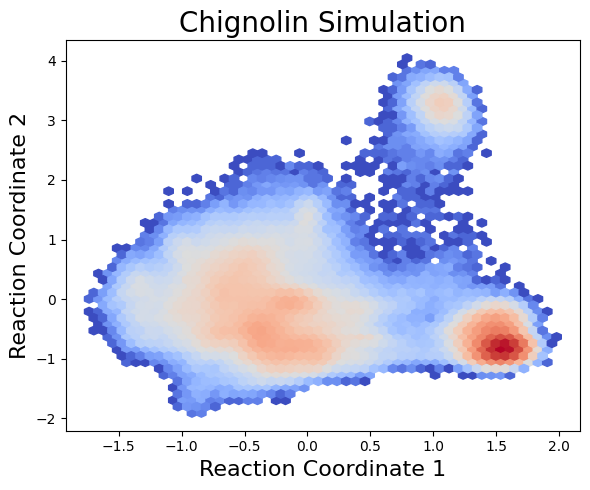

In [2]:
EIGENS_PATH = "/home/ethanz/data_boltz_likelihood/ticas/chignolin_tica_eigenvectors.npy"
MEANS_PATH = "/home/ethanz/data_boltz_likelihood/ticas/chignolin_tica_mean.npy"
GT_TOP_PATH = '/home/ethanz/data_boltz_likelihood/md/chignolin.pdb'
GT_TRAJ_PATH = '/home/ethanz/data_boltz_likelihood/md/chignolin_traj_all.hdf5'

tica_eigenvectors = np.load(EIGENS_PATH)
tica_means = np.load(MEANS_PATH)

def get_chignolin_reaction_coordinates(
    top, 
    r_coordinates,
    mean, 
    eigenvectors,
    device="cuda:0"
):
    """Computes Chignolin RC values for each frame of a trajectory.

    Parameters
    ----------
    top : mdtraj.Topology object
        Topology of the trajectory.

    r_coordinates : np.array of shape (frames, n_atoms, 3)
        Coordinate array of the trajectory.

    Returns
    -------
    all_projections_sub : torch.tensor of shape (frames, 2)
        tICA coordinate values for every frame.
    """
    traj = md.Trajectory(r_coordinates, top).atom_slice(top.select("name CA"))
    distance_indeces = [[i, j] for i in range(traj.n_atoms) 
                    for j in range(i + 1, traj.n_atoms)]
    all_distances = md.compute_distances(traj, distance_indeces)
    all_projections_sub = ((all_distances - mean)  @ eigenvectors)[:, :2]
    return torch.tensor(all_projections_sub)



gt_topology = md.load(GT_TOP_PATH).topology

with h5py.File(GT_TRAJ_PATH, 'r') as file:
    if "positions" not in file.keys():
        raise ValueError("No positions in file")
    positions = file["positions"][:]
    frames_to_save = np.arange(positions.shape[0])
    gt_trajectory = md.Trajectory(
        positions * a_to_nm, # Ground truth positions are in angstroms.
        gt_topology
    )

gt_rcs = get_chignolin_reaction_coordinates(
    gt_topology,
    gt_trajectory.xyz,
    tica_means,
    tica_eigenvectors,
)

plt.figure(figsize=(6, 5))
ax = plt.gca()

hb = ax.hexbin(gt_rcs[:,0], gt_rcs[:,1], gridsize=50, cmap='coolwarm', norm=mcolors.LogNorm())
ax.set_title("Chignolin Simulation", fontsize=20)
ax.set_xlabel("Reaction Coordinate 1", fontsize=16)
ax.set_ylabel("Reaction Coordinate 2", fontsize=16)
plt.tight_layout()
plt.show()

## Defining Umbrella Centers + Getting Starting Structures

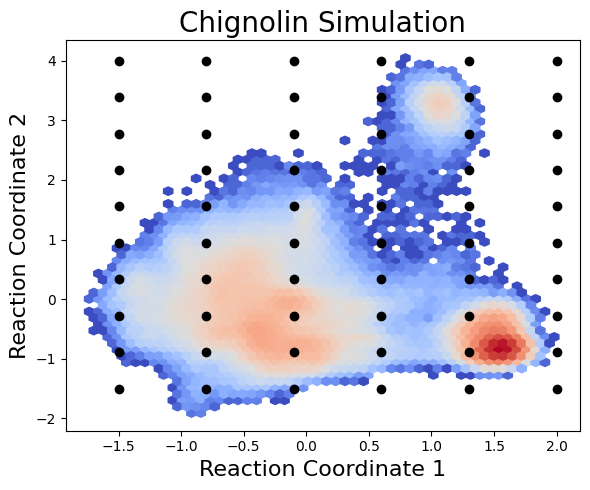

In [3]:
bottom_left = (-1.5, -1.5)
top_right = (2, 4)

num_x = 6  # Number of points in x-direction.
num_y = 10  # Number of points in y-direction.

x_vals = np.linspace(bottom_left[0], top_right[0], num_x)
y_vals = np.linspace(bottom_left[1], top_right[1], num_y)
X, Y = np.meshgrid(x_vals, y_vals)
umbrella_centers = np.stack([X.ravel(), Y.ravel()], axis=-1)

plt.figure(figsize=(6, 5))
ax = plt.gca()

hb = ax.hexbin(gt_rcs[:,0], gt_rcs[:,1], gridsize=50, cmap='coolwarm', norm=mcolors.LogNorm())
ax.scatter(umbrella_centers[:, 0], umbrella_centers[:, 1], color='black')
ax.set_title("Chignolin Simulation", fontsize=20)
ax.set_xlabel("Reaction Coordinate 1", fontsize=16)
ax.set_ylabel("Reaction Coordinate 2", fontsize=16)
plt.tight_layout()
plt.show()

## Saving PDBs of starting structures.

### Checking nearest structures and discarding those that are bad.

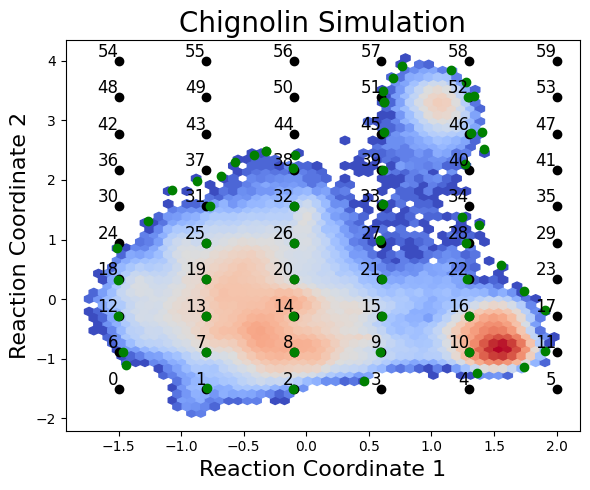

In [4]:
gt_rcs_np = gt_rcs.numpy()
tree = cKDTree(gt_rcs_np)

# Query nearest neighbor in B for each point in A
_, indices = tree.query(umbrella_centers)
closest_points = gt_rcs_np[indices]

plt.figure(figsize=(6, 5))
ax = plt.gca()

hb = ax.hexbin(gt_rcs[:,0], gt_rcs[:,1], gridsize=50, cmap='coolwarm', norm=mcolors.LogNorm())
ax.scatter(umbrella_centers[:, 0], umbrella_centers[:, 1], color='black')
for i, (x, y) in enumerate(umbrella_centers):
    ax.text(x, y, str(i), fontsize=12, ha='right', va='bottom')
ax.scatter(closest_points[:, 0], closest_points[:, 1], color='green')
ax.set_title("Chignolin Simulation", fontsize=20)
ax.set_xlabel("Reaction Coordinate 1", fontsize=16)
ax.set_ylabel("Reaction Coordinate 2", fontsize=16)
plt.tight_layout()
plt.show()

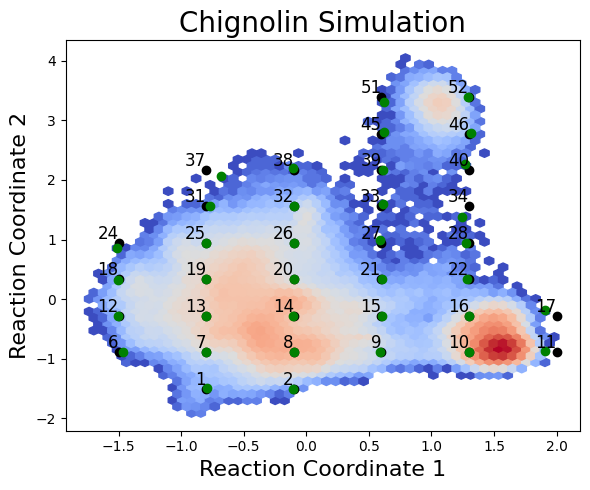

In [5]:
indices_to_discard = [0, 3, 4, 5, 23, 29, 30, 35, 36, 41, 42, 43, 44, 47, 48, 49, 50, 53, 54, 55, 56, 57, 58, 59] # Change as desired.

kept_centers = np.delete(umbrella_centers, indices_to_discard, axis=0)
kept_closest_points = np.delete(closest_points, indices_to_discard, axis=0)
kept_indices = np.delete(np.arange(0, len(indices)), indices_to_discard)

plt.figure(figsize=(6, 5))
ax = plt.gca()

hb = ax.hexbin(gt_rcs[:,0], gt_rcs[:,1], gridsize=50, cmap='coolwarm', norm=mcolors.LogNorm())
ax.scatter(kept_centers[:, 0], kept_centers[:, 1], color='black')
for i, (x, y) in enumerate(kept_centers):
    ax.text(x, y, kept_indices[i], fontsize=12, ha='right', va='bottom')
ax.scatter(kept_closest_points[:, 0], kept_closest_points[:, 1], color='green')
ax.set_title("Chignolin Simulation", fontsize=20)
ax.set_xlabel("Reaction Coordinate 1", fontsize=16)
ax.set_ylabel("Reaction Coordinate 2", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(CENTER_OUTDIR, 'ref.png'))
plt.show()

## Creating master umbrella.json dictionary.

In [11]:
indices_filtered = np.delete(indices, indices_to_discard) # gt_traj frame indices.
ks = [10 for _ in range(len(indices_filtered))] # TODO: change as desired.

master_dict = {}

for i, frame_idx in enumerate(indices_filtered):
    frame = gt_trajectory[frame_idx]
    savepath = os.path.join(CENTER_OUTDIR, f'{kept_indices[i]}.pdb')
    frame.save(savepath)
    master_dict[savepath] = {
        'k': ks[i],
        'cv0': kept_centers[i].tolist()
    }

JSON_SAVE_PATH = '/home/ethanz/boltz-likelihoods/chignolin_umbrella.json'
with open(JSON_SAVE_PATH, 'w') as file:
    json.dump(master_dict, file, indent=2)

## Visualizing an umbrella run.